In [3]:
#import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Introduction / Task Definition

This project will develop a machine learning system for classifying 27x27 RGB histopathology images of colon cells. The work has two prediction targets: a binary task that identifies whether a cell image is cancerous, and a multi-class task that predicts the cell type.

A key requirement is that the model must generalise to new patients, so the dataset will be split at the patient level rather than the image level. This prevents images from the same patient from appearing in both training and evaluation sets, which would otherwise create data leakage and inflate performance.

The overall workflow in this notebook follows a standard machine learning process:
define the task, 
inspect the dataset, 
perform exploratory analysis, 
preprocess the data, 
compare several models, 
tune hyperparameters, 
explore an advanced technique (CP), 
and finally evaluate the selected model on completely unseen patients.

## 2. Load Data / Inspection

In [7]:
DATA_ROOT = "dataset/data"

print("Current directory:", os.getcwd())
print("Dataset folder exists:", os.path.exists(DATA_ROOT))

print("\nFiles in dataset/data folder:")
for item in sorted(os.listdir(DATA_ROOT)):
    print(item)

main_path = os.path.join(DATA_ROOT, "data_labels_mainData.csv")
extra_path = os.path.join(DATA_ROOT, "data_labels_extraData.csv")

main_df = pd.read_csv(main_path)
extra_df = pd.read_csv(extra_path)

print("\nMain labels shape:", main_df.shape)
print("Extra labels shape:", extra_df.shape)

print("\nMain columns:", main_df.columns.tolist())
print("Extra columns:", extra_df.columns.tolist())

display(main_df.head())
display(extra_df.head())

Current directory: C:\Users\Owner\OneDrive - RMIT University\Documents\machinelearning2026\a3
Dataset folder exists: True

Files in dataset/data folder:
data_labels_extraData.csv
data_labels_mainData.csv
images

Main labels shape: (9896, 6)
Extra labels shape: (10384, 4)

Main columns: ['InstanceID', 'patientID', 'ImageName', 'cellTypeName', 'cellType', 'isCancerous']
Extra columns: ['InstanceID', 'patientID', 'ImageName', 'isCancerous']


,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


## 2. Notes
The dataset is loaded using relative paths from `dataset/data` so the notebook remains portable and reproducible. The two label files are read separately because the binary cancer task uses both files, while the cell-type task uses only the main label file.

The output shows that the dataset includes a `patientID` column for patient-level splitting, an `ImageName` column for linking labels to image files, and the target columns `isCancerous` and `cellTypeName`. I inspect the shapes and first rows of both label files to confirm the dataset structure before proceeding to splitting and EDA.

## 3. Exlopartory Data Analysis (EDA)

In [18]:
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


IMAGE_DIR = os.path.join(DATA_ROOT, "images")

main_df = pd.read_csv(os.path.join(DATA_ROOT, "data_labels_mainData.csv"))
extra_df = pd.read_csv(os.path.join(DATA_ROOT, "data_labels_extraData.csv"))

all_cancer = pd.concat(
    [
        main_df[["InstanceID", "patientID", "ImageName", "isCancerous"]],
        extra_df[["InstanceID", "patientID", "ImageName", "isCancerous"]],
    ],
    ignore_index=True
)

print("Main dataset shape:", main_df.shape)
print("Extra dataset shape:", extra_df.shape)
print("Combined cancer dataset shape:", all_cancer.shape)

print("\nUnique patients in main:", main_df["patientID"].nunique())
print("Unique patients in extra:", extra_df["patientID"].nunique())
print("Unique patients in combined cancer set:", all_cancer["patientID"].nunique())

print("\nCancer class balance:")
print(all_cancer["isCancerous"].value_counts().sort_index())

print("\nCell-type balance:")
print(main_df["cellTypeName"].value_counts())

patients_per_image = all_cancer.groupby("patientID").size().reset_index(name="num_images")
print("\nImages per patient summary:")
print(patients_per_image["num_images"].describe())


Main dataset shape: (9896, 6)
Extra dataset shape: (10384, 4)
Combined cancer dataset shape: (20280, 4)

Unique patients in main: 60
Unique patients in extra: 38
Unique patients in combined cancer set: 98

Cancer class balance:
isCancerous
0    13211
1     7069
Name: count, dtype: int64

Cell-type balance:
cellTypeName
epithelial      4079
inflammatory    2543
fibroblast      1888
others          1386
Name: count, dtype: int64

Images per patient summary:
count     98.000000
mean     206.938776
std      154.190190
min        6.000000
25%      100.500000
50%      162.000000
75%      319.000000
max      699.000000
Name: num_images, dtype: float64


### Dataset overview and class balance

The dataset contains 9,896 labelled images in the main file and 10,384 additional cancer-labelled images in the extra file, giving 20,280 total cancer-task examples across 98 patients. The main file also includes the four cell-type labels needed for the multi-class task, while the extra file is restricted to `isCancerous`.

The cancer labels are moderately imbalanced, with more non-cancerous than cancerous examples. The cell-type classes are also unevenly distributed, with epithelial cells forming the largest class and others forming the smallest.

I also checked the number of images contributed by each patient. The distribution is fairly spread out, ranging from very small patients to patients with hundreds of images, which reinforces the need for patient-aware splitting so that heavily represented patients do not dominate the evaluation.

In [19]:
# Basic quality checks
print("Main duplicates:", main_df.duplicated().sum())
print("Extra duplicates:", extra_df.duplicated().sum())

print("\nMain missing values:")
print(main_df.isna().sum())

print("\nExtra missing values:")
print(extra_df.isna().sum())

# Confirm image format on a small sample
sample_paths = [os.path.join(IMAGE_DIR, f) for f in main_df["ImageName"].sample(12, random_state=42).tolist()]
shape_rows = []
for p in sample_paths:
    img = Image.open(p)
    shape_rows.append((os.path.basename(p), img.size, len(img.getbands())))

shape_df = pd.DataFrame(shape_rows, columns=["ImageName", "size", "channels"])
print("\nImage shape check (sample):")
print(shape_df)

# PCA on a subset of images
n = min(1500, len(main_df))
pca_df = main_df.sample(n, random_state=42).reset_index(drop=True)

X = []
for fname in pca_df["ImageName"]:
    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")
    X.append(np.asarray(img).astype(np.float32).reshape(-1))

X = np.vstack(X)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

pca_out = pd.DataFrame({
    "pc1": coords[:, 0],
    "pc2": coords[:, 1],
    "cellTypeName": pca_df["cellTypeName"].values
})

print("\nPCA explained variance ratio:")
print(pca.explained_variance_ratio_)

Main duplicates: 0
Extra duplicates: 0

Main missing values:
InstanceID      0
patientID       0
ImageName       0
cellTypeName    0
cellType        0
isCancerous     0
dtype: int64

Extra missing values:
InstanceID     0
patientID      0
ImageName      0
isCancerous    0
dtype: int64

Image shape check (sample):
    ImageName      size  channels
0    1045.png  (27, 27)         3
1   19809.png  (27, 27)         3
2     370.png  (27, 27)         3
3    4815.png  (27, 27)         3
4    3312.png  (27, 27)         3
5     262.png  (27, 27)         3
6   20575.png  (27, 27)         3
7    1456.png  (27, 27)         3
8   18665.png  (27, 27)         3
9    1059.png  (27, 27)         3
10  17773.png  (27, 27)         3
11  18870.png  (27, 27)         3

PCA explained variance ratio:
[0.21725522 0.04253664]


### Dataset quality checks

I checked the label files for basic data quality issues before moving on to modelling. Both the main and extra label files contain no duplicate rows and no missing values, which suggests that the tabular metadata is clean and ready for analysis.

I also verified the image format using a small sample of files. All sampled images are 27 x 27 pixels with 3 colour channels, which confirms that the dataset has a consistent input shape and is suitable for image-based modelling.

These checks are useful because they reduce the likelihood that later model performance is affected by data corruption, inconsistent formatting, or incomplete labels rather than the underlying classification task.

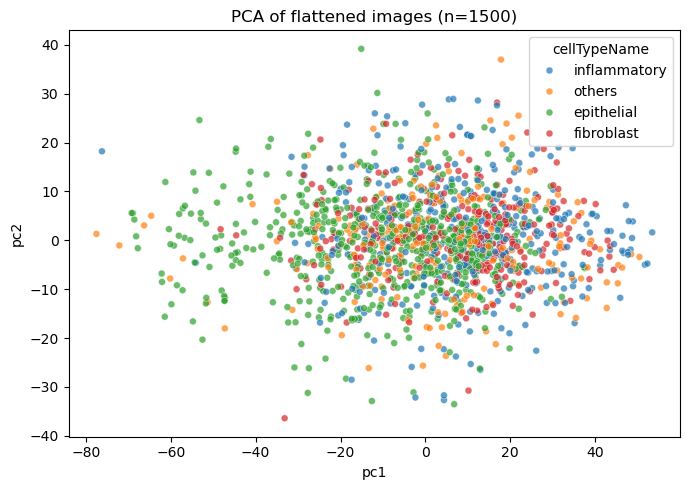

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_out, x="pc1", y="pc2", hue="cellTypeName", s=25, alpha=0.7)
plt.title(f"PCA of flattened images (n={len(pca_out)})")
plt.tight_layout()
plt.show()

### PCA plot notes

The plot also shows a broad spread of points with some mild class-specific tendencies, but no clear boundary. That indicates substantial within-class variation and inter-class similarity, which is typical in histopathology data and helps justify why the modelling stage should focus on richer feature learning rather than relying on manual rules or a simple linear classifier.

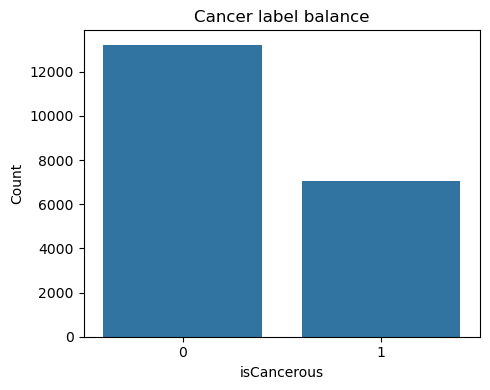

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(data=all_cancer, x="isCancerous")
plt.title("Cancer label balance")
plt.xlabel("isCancerous")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Cancer label balance plot notes
The cancer label distribution shows that the dataset is moderately imbalanced, with more non-cancerous than cancerous examples. This is a useful finding because the cancer task is binary classification, and a skewed class distribution can make accuracy misleading if a model simply favours the majority class.

For this reason, later model comparison should focus on metrics such as macro F1, precision, and recall rather than accuracy alone. The imbalance also supports using a consistent validation framework so that model differences are evaluated fairly on unseen patients.

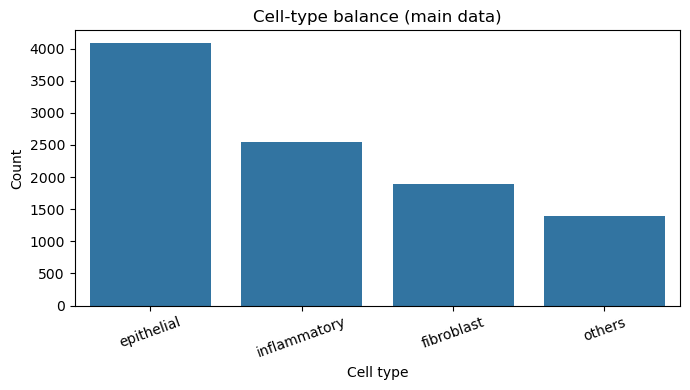

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(data=main_df, x="cellTypeName", order=main_df["cellTypeName"].value_counts().index)
plt.title("Cell-type balance (main data)")
plt.xlabel("Cell type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Cell-type balance plot notes
The cell-type distribution shows clear class imbalance across the four categories, with epithelial cells being the most common and other classes appearing less frequently. This matters because the cell-type task is multi-class and the class frequencies are uneven, so accuracy alone would not be a reliable measure of performance.

This plot justifies the use of macro-averaged F1-score later in the assignment, since macro averaging gives each class equal weight and is more informative when the class distribution is imbalanced. It also suggests that some models may need class weighting, careful tuning, or other imbalance-aware strategies.

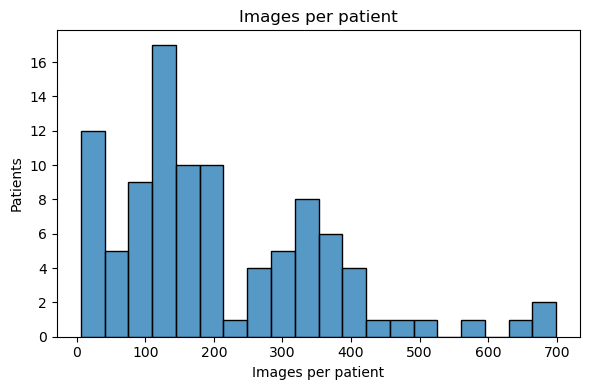

In [14]:
plt.figure(figsize=(6, 4))
sns.histplot(patients_per_image["num_images"], bins=20, kde=False)
plt.title("Images per patient")
plt.xlabel("Images per patient")
plt.ylabel("Patients")
plt.tight_layout()
plt.show()

### Images per patient histogram notes
The histogram of images per patient shows that the dataset is not evenly distributed across patients. Some patients contribute many more image patches than others, which is important because the assignment requires patient-level splitting and evaluation on unseen patients.

This imbalance means that a few patients could otherwise dominate model learning if splitting were done incorrectly. The plot therefore supports the decision to split by `patientID` and helps justify careful evaluation, since the model should generalise across patients rather than memorising a small number of heavily represented cases.

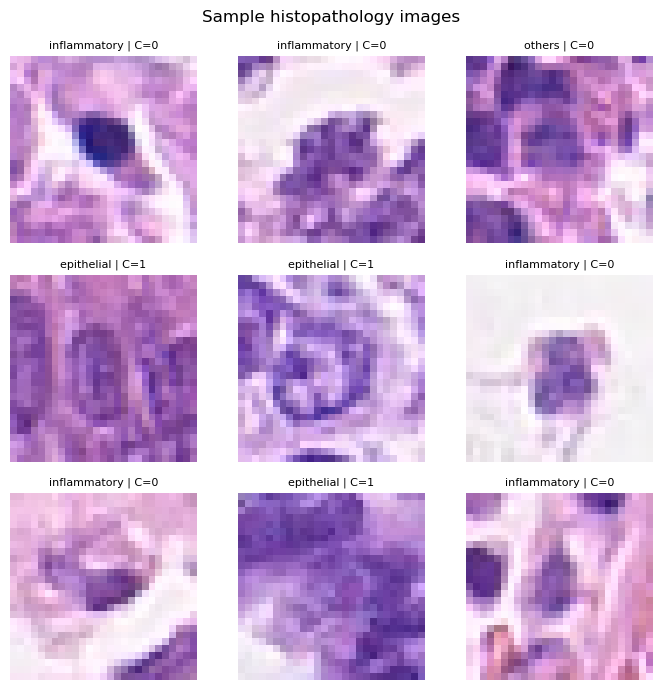

In [15]:
sample_df = main_df.sample(9, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    img_path = os.path.join(IMAGE_DIR, row["ImageName"])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{row['cellTypeName']} | C={row['isCancerous']}", fontsize=8)
    ax.axis("off")
plt.suptitle("Sample histopathology images", y=0.98)
plt.tight_layout()
plt.show()

### Sample images notes
The sample image grid provides a quick visual check that the dataset contains coherent histopathology patches and that the image files are being read correctly. Even at this small resolution, the examples show noticeable differences in texture, staining intensity, and local structure, which suggests that the classification models will need to learn subtle visual patterns rather than simple colour cues.

This plot is also useful for motivating model choice later in the assignment. Because the images are small and visually detailed, classical models on flattened pixels may miss spatial structure, while convolutional neural networks may be better suited to capture local patterns.

## 5. EDA Notes

The EDA section is designed to understand the dataset before any modelling decisions are made. I first inspect the overall dataset sizes, the number of unique patients, and the balance of the `isCancerous` and `cellTypeName` labels. This is important because class imbalance can strongly affect both model choice and evaluation metrics.

I also examine the number of images contributed by each patient so I can understand whether some patients dominate the dataset. Since the assignment requires patient-level generalisation, this is a useful check before building the split and preprocessing pipeline.

I also check for missing values and duplicate rows to confirm that the label files are clean before modelling. These checks help ensure that later performance differences are due to model behaviour rather than basic data quality issues.

I apply PCA to a flattened subset of the images. This provides a simple low-dimensional view of the data and helps indicate whether the cell types form visibly separated groups or whether the classes overlap strongly in pixel space. Since PCA is a projection method that preserves directions of high variance, it is a useful first look at the structure of the image data before any supervised modelling.

Finally, I display a small grid of sample images to confirm that the image files are loading correctly and to get a visual sense of the patterns the models will need to learn. This helps connect the label distributions to the actual appearance of the histopathology images.

